In [1]:
# =================================================================================================
# BAGIAN 1: SETUP DAN IMPORT LIBRARY
# =================================================================================================
import os
import logging
import warnings
import absl.logging

# 🔹 Atur environment & logging SEBELUM import tensorflow
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # hanya error fatal
os.environ["TF_XLA_FLAGS"] = "--tf_xla_enable_xla_devices=false"  # disable XLA agar log CUDA hilang

absl.logging.set_verbosity(absl.logging.ERROR)
logging.getLogger("tensorflow").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")


In [2]:
# =================================================================================================
# BAGIAN 1: SETUP DAN IMPORT LIBRARY
# =================================================================================================
import os

# Hilangkan warning log TensorFlow
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import logging, absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)
logging.getLogger("tensorflow").setLevel(logging.ERROR)

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Install library tambahan tanpa merusak dependency Kaggle
!pip install tensorflowjs -q --no-deps

# Cek versi & GPU
print("Versi TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))


2025-09-14 04:03:46.001859: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757822626.027746     772 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757822626.035143     772 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Versi TensorFlow: 2.18.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# =================================================================================================
# BAGIAN 2: MEMUAT DAN MEMPROSES DATASET CIFAR-10
# =================================================================================================
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Normalisasi
x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encoding
y_train_full = tf.keras.utils.to_categorical(y_train_full, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)


In [5]:
# =================================================================================================
# BAGIAN 3: DATA PREPROCESSING - SPLIT DATASET
# =================================================================================================
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.1, random_state=42
)
print(f"Jumlah data training: {len(x_train)}")
print(f"Jumlah data validasi: {len(x_val)}")
print(f"Jumlah data testing: {len(x_test)}")


Jumlah data training: 45000
Jumlah data validasi: 5000
Jumlah data testing: 10000


In [6]:
# =================================================================================================
# BAGIAN 4: AUGMENTASI GAMBAR
# =================================================================================================
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(x_train)

In [7]:
# =================================================================================================
# BAGIAN 5: PEMBUATAN MODEL CNN SEQUENTIAL
# =================================================================================================
model = Sequential([
    # Blok Konvolusi 1
    Conv2D(32, (3, 3), padding='same', input_shape=(32, 32, 3)),
    BatchNormalization(), Activation('relu'),
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),

    # Blok Konvolusi 2
    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(), Activation('relu'),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),

    # Blok Konvolusi 3
    Conv2D(128, (3, 3), padding='same'),
    BatchNormalization(), Activation('relu'),
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.4),

    # Fully Connected
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


I0000 00:00:1757822746.084769     772 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,13

 Total params: 1,344,170 (5.13 MB)

 Trainable params: 1,342,698 (5.12 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [8]:
# =================================================================================================
# BAGIAN 6: CALLBACKS
# =================================================================================================
checkpoint_path = "cifar10_best_model.keras"

if os.path.exists(checkpoint_path):
    print("Checkpoint ditemukan. Memuat model dari checkpoint...")
    model = tf.keras.models.load_model(checkpoint_path)
else:
    print("Checkpoint tidak ditemukan. Memulai training dari awal.")

callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5, verbose=1)
]



Checkpoint ditemukan. Memuat model dari checkpoint...


In [9]:
# =================================================================================================
# BAGIAN 7: TRAINING MODEL
# =================================================================================================
print("\nMemulai Sesi Training...")
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=64),  # batch size ditingkatkan
    epochs=150,
    validation_data=(x_val, y_val),
    callbacks=callbacks_list,
    verbose=1
)



Memulai Sesi Training...
Epoch 1/150


I0000 00:00:1757822780.568462     827 service.cc:148] XLA service 0x7ca4c0002a70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757822780.568528     827 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1757822781.157946     827 cuda_dnn.cc:529] Loaded cuDNN version 90300


  6/704 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.6880 - loss: 0.8886 

I0000 00:00:1757822786.341207     827 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7047 - loss: 0.8447
Epoch 1: val_accuracy improved from -inf to 0.74720, saving model to cifar10_best_model.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step - accuracy: 0.7047 - loss: 0.8448 - val_accuracy: 0.7472 - val_loss: 0.7308 - learning_rate: 0.0010
Epoch 2/150
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7115 - loss: 0.8178
Epoch 2: val_accuracy did not improve from 0.74720
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.7115 - loss: 0.8178 - val_accuracy: 0.7400 - val_loss: 0.7322 - learning_rate: 0.0010
Epoch 3/150
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7293 - loss: 0.7774
Epoch 3: val_accuracy did not improve from 0.74720
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.7293 - loss: 0.7775 - val_accuracy: 0.7394 - val_loss: 0.8086 - learning_rate: 0.0010
Epoch 4/150
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7382 - loss: 0.7545
Epoch 4: val_accuracy did not impro

Akurasi Training Maksimal : 85.82%
Akurasi pada Test Set     : 86.87%


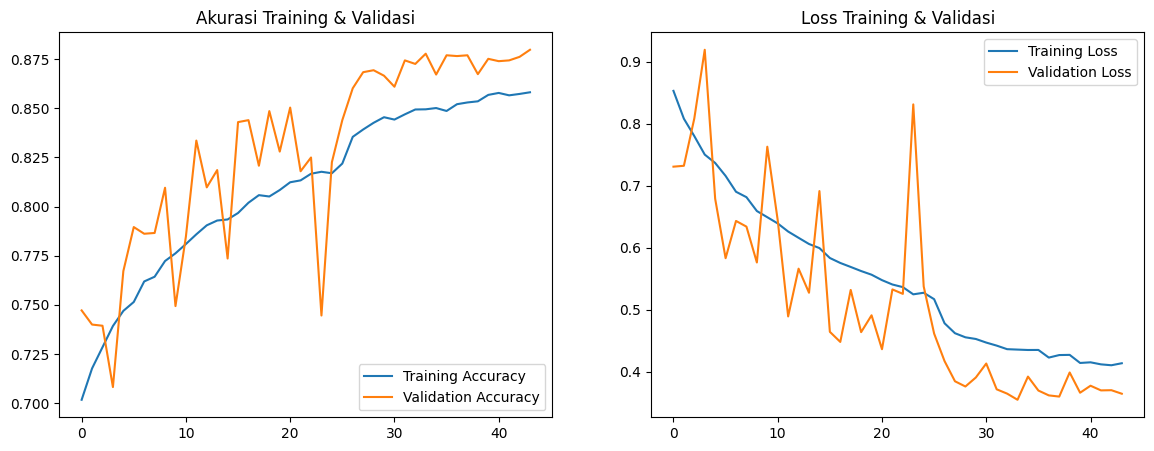

In [10]:
# =================================================================================================
# BAGIAN 8: EVALUASI & VISUALISASI
# =================================================================================================
final_loss, final_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Akurasi Training Maksimal : {max(history.history['accuracy'])*100:.2f}%")
print(f"Akurasi pada Test Set     : {final_acc*100:.2f}%")

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Akurasi Training & Validasi')
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Loss Training & Validasi')
plt.show()

Akurasi Training Maksimal : 85.82%
Akurasi pada Test Set     : 86.87%


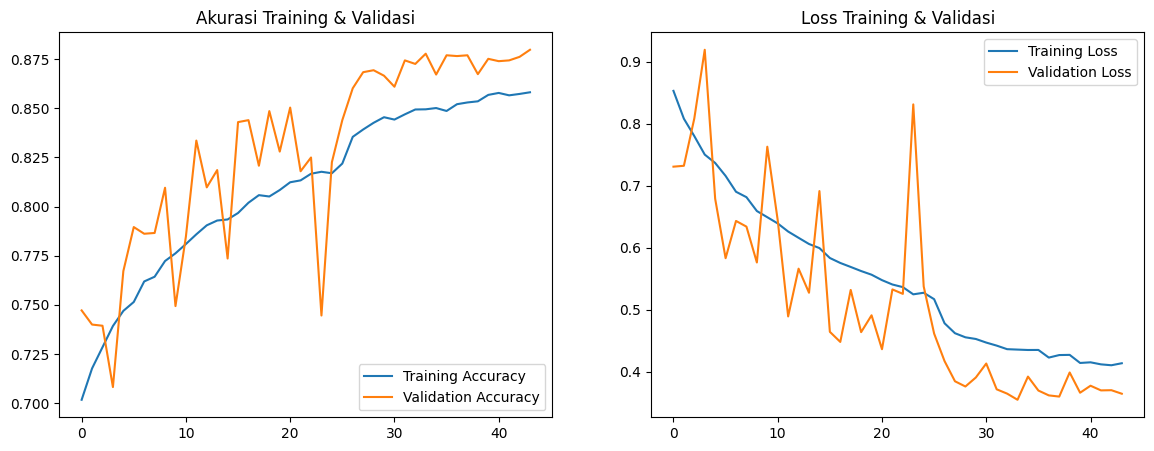

In [11]:
# =================================================================================================
# BAGIAN 8: EVALUASI & VISUALISASI
# =================================================================================================
final_loss, final_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Akurasi Training Maksimal : {max(history.history['accuracy'])*100:.2f}%")
print(f"Akurasi pada Test Set     : {final_acc*100:.2f}%")

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Akurasi Training & Validasi')
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Loss Training & Validasi')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 874ms/step


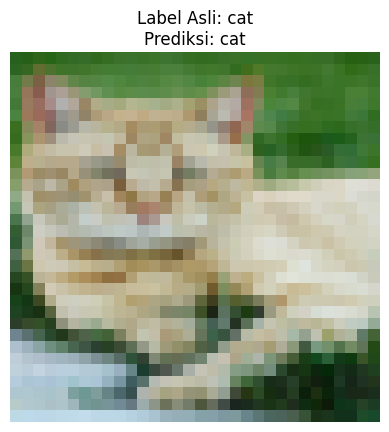

Hasil Prediksi: 'cat' (Probabilitas 97.84%)


In [12]:
# =================================================================================================
# BAGIAN 10: INFERENCE (OPTIONAL)
# =================================================================================================
random_index = np.random.randint(0, len(x_test))
sample_image = x_test[random_index]
sample_label = y_test[random_index]
true_label_name = class_names[np.argmax(sample_label)]

prediction = model.predict(np.expand_dims(sample_image, axis=0))
predicted_label_name = class_names[np.argmax(prediction)]

plt.imshow(sample_image)
plt.title(f"Label Asli: {true_label_name}\nPrediksi: {predicted_label_name}")
plt.axis('off')
plt.show()

print(f"Hasil Prediksi: '{predicted_label_name}' (Probabilitas {np.max(prediction)*100:.2f}%)")



In [14]:
# =================================================================================================
# BAGIAN 11: REQUIREMENTS
# =================================================================================================
import os

# Pastikan folder 'submission' ada
os.makedirs('submission', exist_ok=True)

requirements_content = f"""
tensorflow=={tf.__version__}
numpy
matplotlib
scikit-learn
tensorflowjs
"""
with open('submission/requirements.txt', 'w') as f:
    f.write(requirements_content.strip())

print("✅ File 'requirements.txt' berhasil dibuat di folder 'submission/'")


✅ File 'requirements.txt' berhasil dibuat di folder 'submission/'


In [16]:
import os
import tensorflow as tf
import tensorflowjs as tfjs

# Pastikan folder submission ada
os.makedirs("submission/tfjs_model", exist_ok=True)
os.makedirs("submission/tflite", exist_ok=True)
os.makedirs("submission/saved_model", exist_ok=True)

# 1. Simpan model dalam format SavedModel
model.export("submission/saved_model")

# 2. Simpan model dalam format TensorFlow.js
tfjs.converters.save_keras_model(model, "submission/tfjs_model")

# 3. Simpan model dalam format TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open("submission/tflite/model.tflite", "wb") as f:
    f.write(tflite_model)

# Buat label.txt (contoh untuk CIFAR-10)
labels = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
with open("submission/tflite/label.txt", "w") as f:
    f.write("\n".join(labels))

# 4. Copy Notebook jadi notebook.ipynb
!cp -r /kaggle/working/*.ipynb submission/notebook.ipynb

# 5. Buat README.md
readme_content = """
# Proyek Klasifikasi Gambar

- **Nama:** [SHAH FIRIZKI AZMI]
- **Email:** [m179d5y1836@student.devacademy.id]
- **ID Dicoding:** [M179D5Y1836]

## Deskripsi
Proyek ini menggunakan CNN untuk klasifikasi dataset CIFAR-10.

## Struktur Folder
- `tfjs_model/` → Model untuk TensorFlow.js
- `tflite/` → Model untuk TensorFlow Lite (Android/iOS)
- `saved_model/` → Format TensorFlow SavedModel
- `notebook.ipynb` → Notebook berisi kode pelatihan
- `requirements.txt` → Daftar dependency
"""
with open("submission/README.md", "w") as f:
    f.write(readme_content.strip())


Saved artifact at 'submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  137051167978512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137051167979856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137051167981200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137051167977936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137051167980624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137051167980048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137051111932176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137051111933712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137051111932944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137051111934864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1370511119

W0000 00:00:1757824564.828775     772 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1757824564.828823     772 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1757824564.846439     772 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled
